# Lab: Extreme Events

Savannah Fox, Sree Srinivasan, Keshav Bhakta, Paola Quiroga, Jake McMillan

## Modeling the Unusual

- For a given sample, the maximum and minimum are fixed
- But if we have a large number of samples, we can study the distribution/density of those max/min draws
- Imagine:
    - The biggest storm in a year
    - The worst loss for the market in a month
    - The biggest earthquake in a decade
    - The longest time between goals in a game
- This is how we understand the distribution/density of extreme events
- The **$k$-th order statistic** is the $k$-th largest value in a sample of $n$ from some distribution
- The minimum is the first order statistic and the maximum is the $n$-th order statistic

## Example: Drawing from a Gaussian

Below, we find the minimum of a sample of size n drawn from a normal distribution, and then repeat this b times, to get a distribution of the minimum with 10000 counts in it. This is the distribution of the 1st order statistic, shown below in blue.

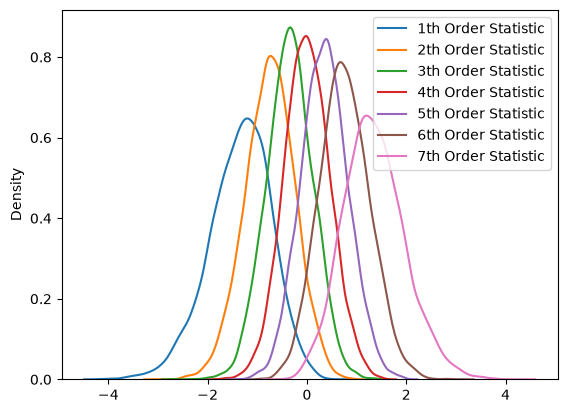

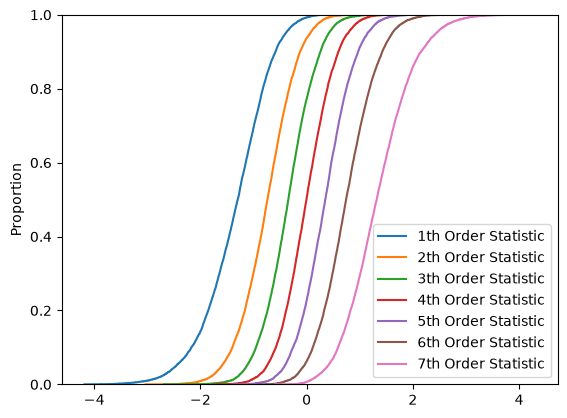

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

rng = np.random.default_rng( seed = 100 ) # Create a random number stream

n = 7 # Sample Size
b = 10_000 # Number of Simulations

sample = rng.standard_normal( size = (n,b) ) # Draw a sample from the standard normal distribution
sorted_sample = np.sort(sample, axis=0) # Sort each column (each simulated sample of size n)

for j in range(n): # For each rank
    sns.kdeplot( sorted_sample[j,:], label=f'{1+j}th Order Statistic') # Plot the KDE
plt.legend() # Add legend
plt.show()

for j in range(n): # For each rank
    sns.ecdfplot( sorted_sample[j,:], label=f'{1+j}th Order Statistic') # Plot the ECDF
plt.legend() # Add legend
plt.show()

## Analytic Relationship

### Maximum
If $F(x)$ is the underlying true CDF, let's consider the analytical equation for the distribution of the maximum of a sample of size $n$. (The maximum is its own random variable, with its distribution plotted above. What is this in math?) To build the CDF of the maximum, we ask (as always): "What's the probability the maximum lands at or below x?" for every x. In other words:
$$F_{max}(x) = P(X_{max} \leq x)$$

This is nothing new, just applying it to the distribution of a specific order statistic, the max.

So what is the **probability that all of the draws are less than or equal to $x$**, i.e. what is the probability that the maximum is less than or equal to $x$ (the right hand side)? Because each draw is independent:

$$P(X_1 \leq x \ ..., X_n \leq x) = P( X_1 \leq x) \cdot P( X_2 \leq x ) \cdot ... \cdot  P( X_n \leq x)$$

Because we are pulling from the same distribution every time, **each of these probabilities equals our CDF, $F(x)$**:

$$P(X_1 \leq x, ..., X_n \leq x) = F(x) \cdot F(x) ... \cdot F(x)$$

The probability that all of the draws are less than or equal to x is therefore:

$$ F_{\max}(x) = F(x) \cdot F(x) \cdots F(x) = F(x)^n $$

What is its density?

## Minimum
The distribution of the minimum is somewhat harder, because our CDF is asking $\leq x$, and "max $\leq x$" means "all $\leq x$" but "min $\leq x$" does not mean "all $\leq x$". We can't just substitute in multiple copies of $F(x)$.  Instead of looking at the probability that all draws are less than or equal to $x$, we need to know the probability that at least one is.

We want to ask "is the minimum less than or equal to x?" which is the opposite of asking "are all of the draws, including the minimum, above x?" The probability that all observations are above $x$ is $(1-F(x))^{n}$. Because this is the opposite of the question we actually want to ask, the complementary probability is what we truly want:

$$ F_{min}(x) = 1 - (1-F(x))^n $$

What is its density?

## All of the other order statistics, generally
- If you're curious, the density of the $k$-th of $n$ order statistics is

$$
f_k(x) = \dfrac{n!}{(k-1)!(n-k)!} F(x)^{k-1} (1-F(x))^{n-k}f(x)
$$

- We'll use the results for the minimum and maximum

## The Data

We have three datasets:

1. Rainfall *totals* for every state-month from 1981 to 2025, with 5 reporting stations per state each month
2. Rainfall for every *station-day* over that same 1981-2025 period (same 5 stations per state) — much bigger, and used for a single question near the end of Step One
3. Daily and monthly U.S. stock market returns from 1926 to 2026

We want to understand tail behavior, to better reason about risk (engineering, financial, etc.).


In [7]:
df = pd.read_parquet("data/ghcn_prcp_monthly.parquet")
df.head()

ImportError: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - `Import pyarrow` failed. pyarrow is required for parquet support. Use pip or conda to install the pyarrow package.
 - `Import fastparquet` failed. fastparquet is required for parquet support. Use pip or conda to install the fastparquet package.

**Step One.** 1. Plot the ECDF and KDE of `prcp_total_mm` — the distribution and density of rainfall across the entire U.S.

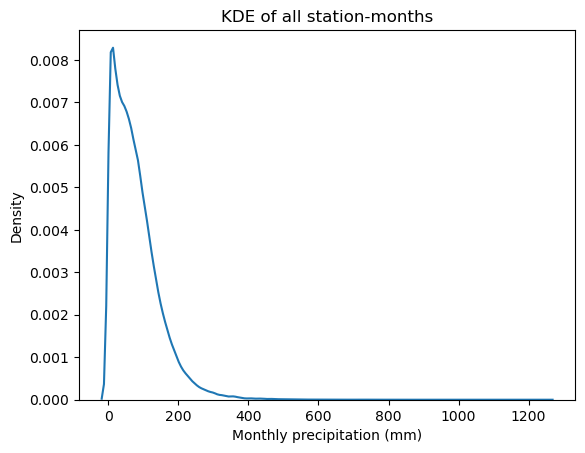

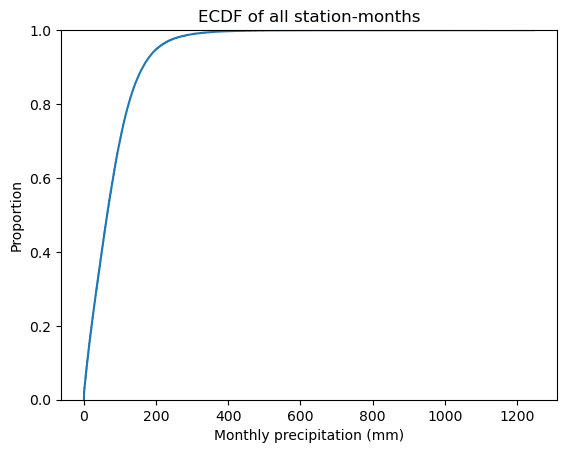

In [ ]:
sns.kdeplot( x=df['prcp_total_mm'])
plt.xlabel("Monthly precipitation (mm)")
plt.title("KDE of all station-months")
plt.show()

sns.ecdfplot( x=df['prcp_total_mm'])
plt.xlabel("Monthly precipitation (mm)")
plt.title("ECDF of all station-months")
plt.show()

2. Now group by year-month and compute the **median** and **maximum** precipitation nationwide. Plot the ECDF and KDE of these two statistics.

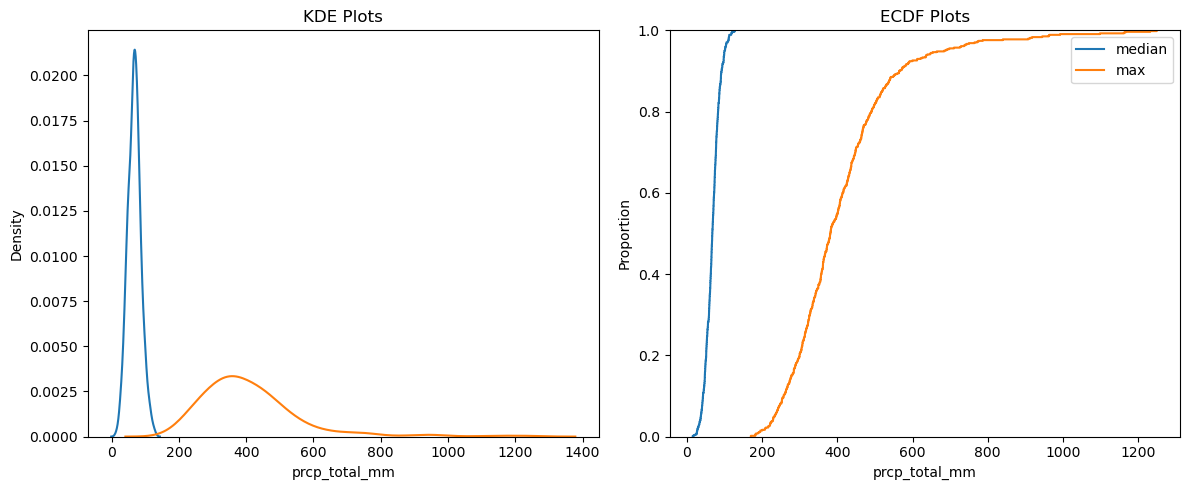

In [ ]:
df_max = (
    df.groupby(['year', 'month'])['prcp_total_mm']
      .max()
      .reset_index())
df_median = (
    df.groupby(['year', 'month'])['prcp_total_mm']
      .median()
      .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
## Plot the KDEs
sns.kdeplot(data=df_median, x="prcp_total_mm", label='median', ax=axes[0])
sns.kdeplot(data=df_max, x="prcp_total_mm", label='max', ax=axes[0])
axes[0].set_title("KDE Plots")
## Plot the ECDFs
sns.ecdfplot(data=df_median, x="prcp_total_mm", label='median',  ax=axes[1])
sns.ecdfplot(data=df_max, x="prcp_total_mm", label='max', ax=axes[1])
axes[1].set_title("ECDF Plots")
## Clean up layout and display
plt.tight_layout()
plt.legend()
plt.show()

3. How do your results in part 2 compare to your results in part 1?

> **1. Compare and contrast the ECDFs and KDEs from parts 1 and 2. Explain why they are different:** 

**Answer**: In part one, the plots use every single station's month data, so they show how rainfall is spread out overall. The KDE peaks really early in the low teens of millimeters and then drops off pretty fast. There is a very long tail of really wet months that stretch past 1,200 mm. The ECDF matches this too, since it shoots up quickly and is already close to 1 by about the 300 mm range. That tells us most station months have fairly low rainfall, and only a few are really wet.

In part two, we take that median and the max for each year/month, so they are different things than the raw data. The median KDE is a tall, narrow spike centered at about 65 to 70 mm, and the ECDF goes from 0 to 1 over a really short range, from about 0 to 125 mm-ish. That's because the middle value doesn't change from month to month, and the extreme months don't pull it around. The max is way farther to the right. Its KDE is a lot lower and wider, with a peak around 350 to 400 mm and a tail that goes out past 1,200 mm again. Its ECDF doesn't start until about 170 mm, and it's spread out all the way to about 1,250 mm. This is because it is the single wettest station month of each year/month.

The real difference between the two parts is that they describe different random variables. In part one, it's a single station month, and in part two, it is the median or the maximum of a group of them. 

4. Now define a state's rainfall differently: take the **median** of the 5 stations in each month, then find the **maximum** across the state's 12 months in a year — the "wettest month." For each state, what's the expected value of the wettest month? Plot the ECDF of Virginia's annual maxima (the wettest month in each of the 45 years), and overlay the analytical prediction $F_{\max}(x) = \hat F(x)^{12}$.

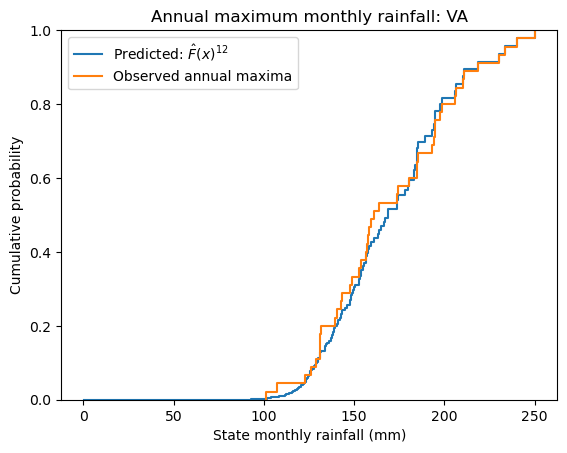

In [ ]:
# One rainfall value per state-month, taking the median of the stations
state_month = (
    df.groupby(["state", "year", "month"], as_index=False)
      .agg(prcp_total_mm=("prcp_total_mm", "median")))

# Maximum of the 12 state-month observations above, for each year: the wettest month of that year
state_year_max = (
    state_month.groupby(["state", "year"], as_index=False)
               .agg(prcp_total_mm=("prcp_total_mm", "max")))

exp_wettest = state_year_max.groupby("state", as_index=False).agg(E_wettest_month=("prcp_total_mm", "mean"))
exp_wettest.loc[exp_wettest["state"] == "VA"]


state = "VA"

levels = (
    state_month.loc[state_month["state"] == state, "prcp_total_mm"]
    .to_numpy()
)

observed_max = (
    state_year_max.loc[state_year_max["state"] == state, "prcp_total_mm"]
    .to_numpy()
)

x = np.sort(np.unique(levels))
F_hat = np.searchsorted(np.sort(levels), x, side="right") / len(levels)

plt.step(
    x,
    F_hat**12,
    where="post",
    label=r"Predicted: $\hat F(x)^{12}$"
)

sns.ecdfplot(x=observed_max,
    label="Observed annual maxima")

plt.xlabel("State monthly rainfall (mm)")
plt.ylabel("Cumulative probability")
plt.title(f"Annual maximum monthly rainfall: {state}")
plt.legend()
plt.show()

> **2. How close is the fit here? If it differs from question 4's fit, why:** _(double-click to edit this cell)_

**Answer**: The fit is actually pretty close for Virginia. The predicted curve and the observed annual maxima follow each other almost the whole way, going from about 100 mm to 250 mm. They only separate a little in very, very few spots that are noticeable to the eye, like around 130 mm. On the plot, the observed curve sits a bit above the prediction at about 150 to 165 mm. 

With that being said, the small gaps are mostly because the observed curve only has 45 data points, one for each year, so it's a jagged staircase situation. The prediction is smoother because it uses all the monthly data, and the formula can also be off a bit because it assumes that the 12 months are all the same and independent. Rainfall isn't perfectly like that. Rainfall varies by season, so some months are wetter than others. 

For Virginia, that doesn't really matter much, which is why the curves line up so well. If we were comparing other states, this might not be an accurate representation.  Since this fit is only for Virginia (using the same setup as question 4: the median of the five stations each month, then the maximum across the 12 months of each year), I can't say whether other states would fit as closely from what's shown in this notebook.  

5. **A question for FEMA.** So far you've worked with *monthly* rainfall totals. Switch now to the daily station-level file (`ghcn_prcp_daily.parquet`) — reload `df` from it, and don't mix it with the monthly data above.

   A day with more than 120mm of rain is a serious flood/landslide risk. On any single station-day, that's rare. But a state doesn't get one chance a month — it gets 5 stations $\times$ (days in the month) chances. FEMA doesn't care about the average day, or the single worst day on record; it cares about the probability that *some* station has a disaster day at some point during the month.

   For each state-month, estimate
   $$P(\text{at least one station-day exceeds 120mm}) = 1 - \hat F(120)^n$$
   where $\hat F$ is the empirical CDF of a single station-day's rainfall for that state and calendar month (pooled across all years), and $n$ is the number of station-days in one occurrence of that month (5 stations $\times$ days in the month). Report the 20 highest-risk state-months.


,state,month,p_any_station_day_exceeds_120mm
122,HI,3,0.387166
104,FL,9,0.373367
130,HI,11,0.359242
208,LA,5,0.359229
131,HI,12,0.344789
121,HI,2,0.330060
105,FL,10,0.330026
476,SC,9,0.299512
207,LA,4,0.299512
319,NC,8,0.283726


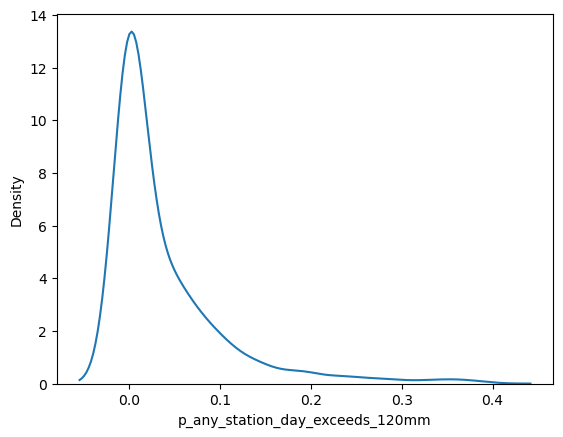

In [ ]:
# Fresh load -- this question uses only the daily file, not the monthly one above.
#df_daily = pd.read_parquet("data/ghcn_prcp_daily.parquet")

url = (
    "https://www.dropbox.com/scl/fi/"
    "pjmyop3fqjdy8oabkc4ab/ghcn_prcp_daily.parquet"
    "?rlkey=otxenczb3pxgzz53kc1i5zxww&dl=1"
)
df_daily = pd.read_parquet(url)
df_daily = df_daily.loc[df_daily["observed"]]

threshold = 120  # mm in a single day

def disaster_risk(group):
    F_hat = (group["prcp_mm"] <= threshold).mean()
    n = len(group) / group["year"].nunique()  # station-days in one year's occurrence of this month
    return 1 - F_hat**n

risk = (
    df_daily.groupby(["state", "month"])
            .apply(disaster_risk, include_groups=False)
            .rename("p_any_station_day_exceeds_120mm")
            .reset_index()
            .sort_values("p_any_station_day_exceeds_120mm", ascending=False)
)

sns.kdeplot(risk['p_any_station_day_exceeds_120mm'])

risk.head(20)

> **3. Which states and months face the most risk of a greater-than-120mm day? How high is the probability? Among all state-months, describe the density of high precipitation days:** _(double-click to edit this cell)_

**Answer**: The top 5 states and corresponding month that is most at risk of a greater-than-120mm day of rainfall is Hawaii in March with a probability of 38.72%, Florida in September with a probability of 37.34%, Hawaii in November with a probability of 35.924%, Lousiana in May with a probability of 35.922%, and Hawaii in December with a probability of 34.48%. Among the top 20 these three state are the most common states to appear. The most common month to appear in the top 20 is August. 

Among all states and months the density of high precipitation days is concentrated below 10% of days a month. The peak of the density for high precipitaion days appears to be just above zero at a denity of about 13.5.

**Step Two.**

Our second data set is daily and monthly U.S. stock market returns. Instead of storms across space (five stations in a state) or across the calendar (twelve months in a year), the "sample" is the set of trading days within a month, and we ask about the best and worst day in that sample.

In [ ]:
df = pd.read_parquet("data/ff_market_daily.parquet")

print(f"{len(df):,} trading days")
print(f"{df['date'].min().date()} through {df['date'].max().date()}")
df.head()

26,296 trading days
1926-07-01 through 2026-07-31


,date,year,month,month_start,trading_day_of_month,mkt_excess_return_pct,risk_free_return_pct,market_return_pct,absolute_market_return_pct
0,1926-07-01,1926,7,1926-07-01,1,0.09,0.01,0.10,0.10
1,1926-07-02,1926,7,1926-07-01,2,0.45,0.01,0.46,0.46
2,1926-07-06,1926,7,1926-07-01,3,0.17,0.01,0.18,0.18
3,1926-07-07,1926,7,1926-07-01,4,0.09,0.01,0.10,0.10
4,1926-07-08,1926,7,1926-07-01,5,0.22,0.01,0.23,0.23


1. Plot the KDE and ECDF of daily market returns.

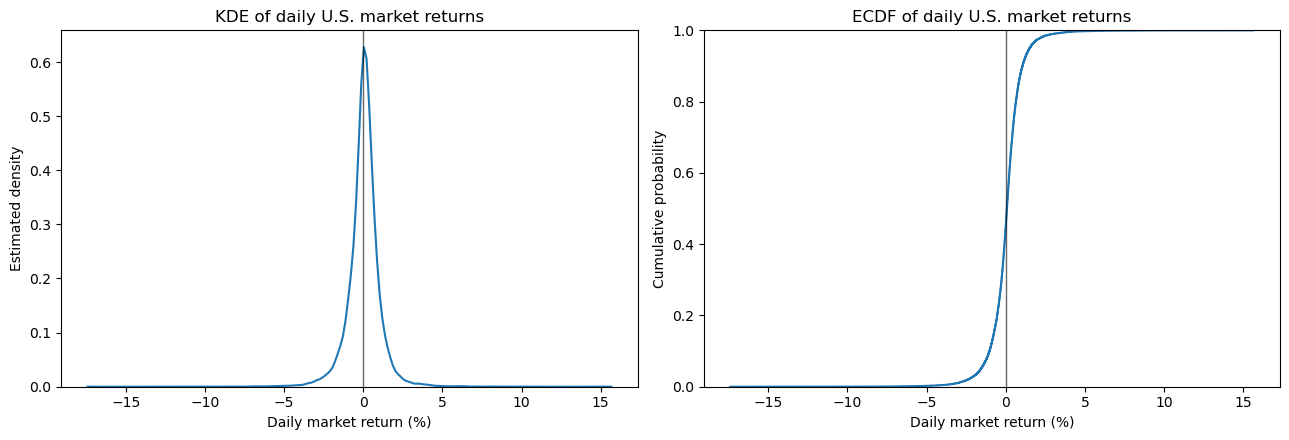

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.kdeplot(
    data=df,
    x="market_return_pct",
    cut=0,
    ax=axes[0],
)
axes[0].axvline(0, color="black", linewidth=1, alpha=0.6)
axes[0].set(
    title="KDE of daily U.S. market returns",
    xlabel="Daily market return (%)",
    ylabel="Estimated density",
)

sns.ecdfplot(
    data=df,
    x="market_return_pct",
    ax=axes[1],
)
axes[1].axvline(0, color="black", linewidth=1, alpha=0.6)
axes[1].set(
    title="ECDF of daily U.S. market returns",
    xlabel="Daily market return (%)",
    ylabel="Cumulative probability",
)

plt.tight_layout()
plt.show()

2. For each calendar month, compute the **best** (max) and **worst** (min) daily return — the first and $n$-th order statistics of that month's trading days. Plot the KDE of the monthly best and worst returns, overlaid.

In [ ]:
monthly = (
    df.groupby(["year", "month"], as_index=False)
         .agg(
             month_start=("month_start", "first"),
             trading_days=("date", "size"),
             worst_return_pct=("market_return_pct", "min"),
             best_return_pct=("market_return_pct", "max"),
             median_return_pct=("market_return_pct", "median"),
         )
)

# Put losses and gains on the same positive-magnitude scale.
monthly["worst_loss_pct"] = -monthly["worst_return_pct"]

print(f"{len(monthly):,} calendar months")
print(
    f"Trading days per month: {monthly['trading_days'].min()} "
    f"to {monthly['trading_days'].max()}"
)
monthly.head()

1,201 calendar months
Trading days per month: 15 to 27


,year,month,month_start,trading_days,worst_return_pct,best_return_pct,median_return_pct,worst_loss_pct
0,1926,7,1926-07-01,25,-0.72,1.10,0.18,0.72
1,1926,8,1926-08-01,26,-1.39,0.85,0.32,1.39
2,1926,9,1926-09-01,24,-0.98,0.91,-0.03,0.98
3,1926,10,1926-10-01,25,-1.81,1.53,-0.09,1.81
4,1926,11,1926-11-01,24,-0.62,0.67,0.19,0.62


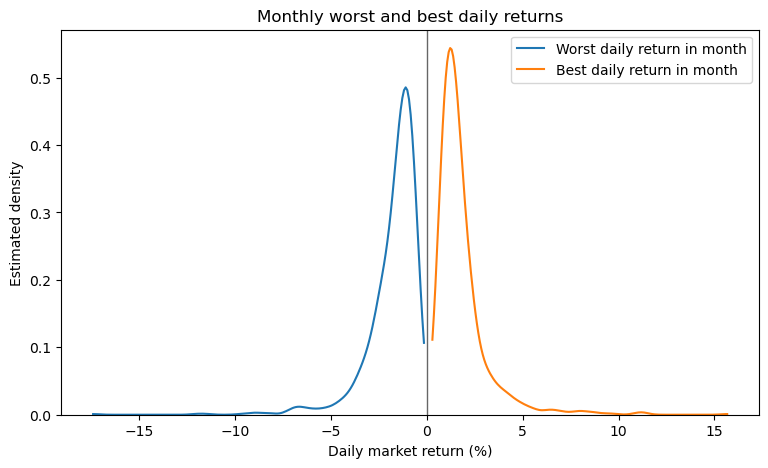

In [ ]:
plt.figure(figsize=(9, 5))
sns.kdeplot(
    x=monthly["worst_return_pct"],
    label="Worst daily return in month",
    cut=0,
)
sns.kdeplot(
    x=monthly["best_return_pct"],
    label="Best daily return in month",
    cut=0,
)
plt.axvline(0, color="black", linewidth=1, alpha=0.6)
plt.xlabel("Daily market return (%)")
plt.ylabel("Estimated density")
plt.title("Monthly worst and best daily returns")
plt.legend()
plt.show()

> |**4. Describe the symmetry (or lack of it) between the best- and worst-day densities. Compare them to the overall populations of daily returns.:** _(double-click to edit this cell)_

**Answer**: There is a mirrored similarity between the worst and best daily return but they are not symetrical. Both graphs peak at their respective positive/negative 2.5%. The best daily returns peaks higher at about 0.55 denstiy while the worst daily return peaks at about .475. Both graph densities are concentrated before positive/negative 5%. The worst daily return graphs has an additional small bump at -7 before it begin to flatten toward zero whereas the best daily returns graph flattens toward zero immediatly after 5. The best daily returns has a shorter tail at 16% than the worst daily returns whose tail trails to about -18%. The graph shows that in the best and worst case of returns in a month that most of the worst and best cases will be within positicve/negative 5% return on investment, The best case is more concentrated . In the extremes (tails) the graph shows that in the worst worst case you will lose more than you gain in the best best case. 

The overall population of daily returns density is highly concentrated around zero where as the best daily returns peak at 2.5% and the worst daily return peak at -2.5%. The peak of the overall population is skewed just slightly in the positive direction at a density of 0.65 which line up with the the peak of the best daily returns peaking higher than worst daily returns. After positive/negative 5% both tails are very closely approaching zero which matches the density concentrations of the worst and best daily returns combined. The tails on the side of negative returns extends longer than the tail of the side of positive returns which aligns with the worst daily return graph that shows that on the worst worst day you will lose more than you gain in the best best case. 


3. Losses and gains are on opposite sides of zero, which makes them hard to compare directly. Put them on the same scale by looking at the *magnitude* of the worst loss (`-worst_return_pct`) against the magnitude of the best gain (`best_return_pct`). Plot both the KDE and ECDF.

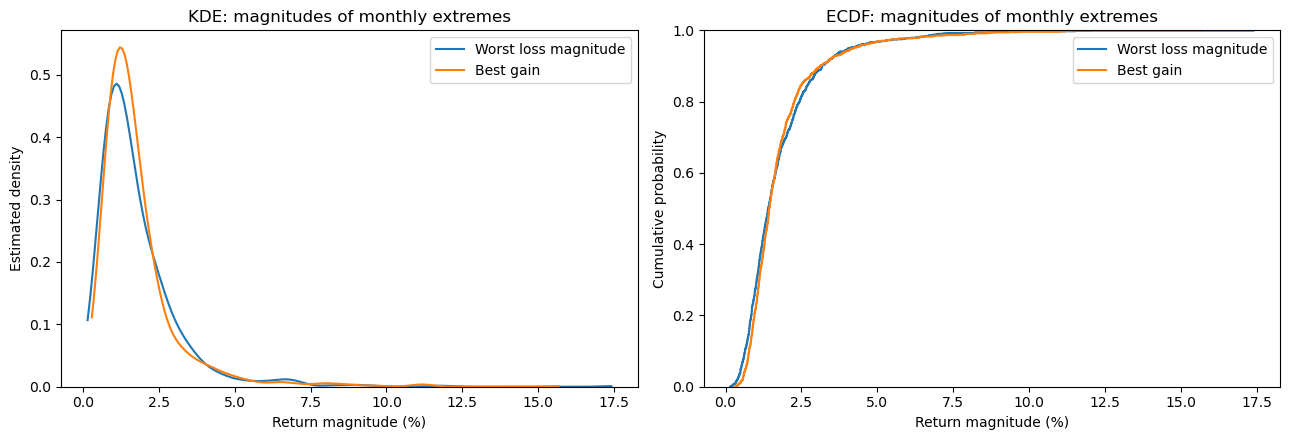

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.kdeplot(
    x=monthly["worst_loss_pct"],
    label="Worst loss magnitude",
    cut=0,
    ax=axes[0],
)
sns.kdeplot(
    x=monthly["best_return_pct"],
    label="Best gain",
    cut=0,
    ax=axes[0],
)
axes[0].set(
    title="KDE: magnitudes of monthly extremes",
    xlabel="Return magnitude (%)",
    ylabel="Estimated density",
)
axes[0].legend()

sns.ecdfplot(
    x=monthly["worst_loss_pct"],
    label="Worst loss magnitude",
    ax=axes[1],
)
sns.ecdfplot(
    x=monthly["best_return_pct"],
    label="Best gain",
    ax=axes[1],
)
axes[1].set(
    title="ECDF: magnitudes of monthly extremes",
    xlabel="Return magnitude (%)",
    ylabel="Cumulative probability",
)
axes[1].legend()

plt.tight_layout()
plt.show()

> **5. Are large losses more extreme than large gains, or about the same:** _(double-click to edit this cell)_

**Answer**:  They are about the same. The KDEs and ECDFs of the worst loss and best gain magnitudes largely overlap, with almost the same medians. Losses run slightly larger in about 75th percentile based on the graph. The two look to be about equal at the 90th percentile, and the largest gains actually exceed the worst losses past the 95th percentile. 


4. Compute the median, 75th, 90th, 95th, and 99th percentile of both magnitudes from question 3. In what fraction of months does the worst loss exceed the best gain in magnitude?

In [ ]:
tail_summary = pd.DataFrame(
    {
        "Worst loss magnitude": monthly["worst_loss_pct"],
        "Best gain": monthly["best_return_pct"],
    }
).quantile([0.50, 0.75, 0.90, 0.95, 0.99]).T

tail_summary.columns = ["median", "75%", "90%", "95%", "99%"]

print(
    "Fraction of months in which the worst loss exceeded the best gain: "
    f"{(monthly['worst_loss_pct'] > monthly['best_return_pct']).mean():.1%}"
)
tail_summary.round(2)

Fraction of months in which the worst loss exceeded the best gain: 44.8%


,median,75%,90%,95%,99%
Worst loss magnitude,1.41,2.21,3.18,4.06,6.97
Best gain,1.44,2.04,3.12,4.21,7.93


> **6. What does this tail comparison say about the risk of losses vs. gains:** _(double-click to edit this cell)_

**Answer**: The tails are roughly symmetric. The median magnitudes are nearly identical 1.41% vs. 1.44%. Losses are slightly larger at the 75th percentile 2.21 vs. 2.04, about equal at the 90th 3.18 vs 3.12, and the largest gains actually exceed the worst losses at the 95th and 99th percentiles 4.21 vs. 4.06 and 7.93 vs. 6.97. At the daily level, extreme losses are not more extreme than extreme gains.


5. Plot the monthly best and worst daily returns over time. Do the extremes look stable across this ~100-year history, or are there periods where they're much larger? Can you identify any famous market events?

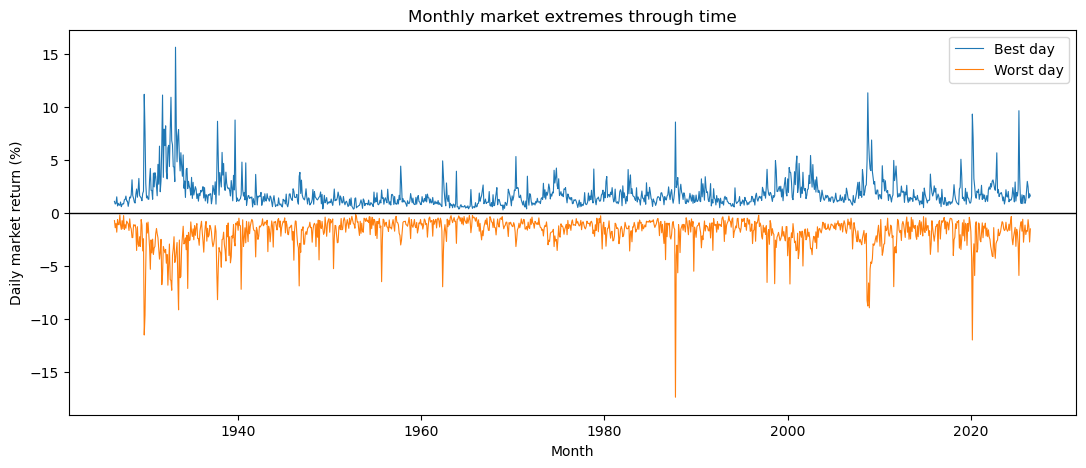

In [ ]:
plt.figure(figsize=(13, 5))
plt.plot(
    monthly["month_start"],
    monthly["best_return_pct"],
    linewidth=0.8,
    label="Best day",
)
plt.plot(
    monthly["month_start"],
    monthly["worst_return_pct"],
    linewidth=0.8,
    label="Worst day",
)
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Month")
plt.ylabel("Daily market return (%)")
plt.title("Monthly market extremes through time")
plt.legend()
plt.show()

> **7. Do upside and downside risk tend to go together (volatility), or does the market exhibit distinct periods in which the good shocks are concentrated and the bad shocks are concentrated? What implication does this have for investing?:** _(double-click to edit this cell)_

**Answer**: Based on the graph above, upside and downside risk seem to mirror each other. In the plot, the big best days and the big worst days show up in the same stretches, like the early 1930s, around 2008 and 2020, and the market is much calmer in other decades. So it isn't one period of only good and another of just bad. The market has periods of high volatility where both gains and big losses are more likely. This shows that investing in short increment (day-trading) is incredibly difficult since a market can do good or poorly on any particular day. With the volatility shown on the graph, it would make more sense to invest for long periods of time so you can benefit from more predictable macro trends.

## Wrap-up



> **8. This week has focused on kernel density estimation, particularly estimating the PDF from data. This lab takes that a step further: We can estimate and quantify the densities and distributions of random variables that build off of observed phenomena. What is the difference between the ECDF and KDE? Explain how these estimations today give us different information than an ECDF or KDE plot of the underlying data, but quantify information about the behavior of a different random variable.:** _(double-click to edit this cell)_

**Answer**: The ECDF and KDE estimate different things using the same data. The ECDF counts what fraction of the data falls at or below each value. The ECDF is exact and looks like a staircase that ascends as you move rightward. The KDE takes the same data and smooths it into a curve which allows us to see the shape of the density. For the KDE, the shape depends on the bandwidth you pick. A smaller bandwidth means that the estimate will be more jagged and have a higher variance. A higher bandwidth means that the estimate will be more smooth and have a high bias.

The order statistics today are not describing the same random variable as the underlying data. An ECDF or KDE of the raw data tells us about a single event, such as a single day of rainfall or a single day of market returns. The maximum or minimum over a group of draws is a new random variable that is built from all of those draws and behaves differently.

In the market data above, the KDE of daily returns tells us what a normal day looks like. The KDE of monthly["worst_return_pct"] and monthly["best_return_pct"] tells us the worst and best day within each month and this is entirely a different variable. The results show that 44.8% of the time, the worst loss in a month beat the best gain in a month in magnitude. At the 99th percentile, the worst loss  was 6.97% against a best gain of 7.93%. None of these values show up in the KDE of individual daily returns because they only describe a typical day.

The same is true with the rainfall data. A single station having a 120mm of rain day is rare. However, asking if any of the 5 stations in a state has a 120mm day in a given month is a very different question. The probability jumps up, for example 38.7% for Hawaii in March or 37.3% for Florida in September. The ECDF of daily rainfall cannot answer that question because it describes one station-day and not the chance that at least one heavy rain day shows up across a batch of them.

The Virginia plot shows this idea in a formula.

$F_{max}(x) = \hat F(x)^{12}$

This formula takes the ECDF of a single month and raises it to the 12th power. This gives the distribution of the worst month in a year which is a random variable that concentrates in the tail of the original distribution and narrows as the sample size grows.